# Visualize Border Matching: Real vs Synthetic Images

This notebook visualizes the new preprocessing approach where borders are added to synthetic images to match real images.

**Key Changes:**
- Real images: Kept as-is (with borders from SquarePad)
- Synthetic images: Borders added to match real images
- No stretching of real images
- Consistent preprocessing for FID



In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import torchvision.transforms as transforms
import torch.nn.functional as F
from typing import Dict, Optional, Tuple, List


In [3]:
# Configuration
validation_images_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/output/roentgen_v2_baseline/validation_images/step_2500")
num_pairs_to_show = 5  # Number of image pairs to display
gpu_dir = validation_images_dir / "gpu_0"  # Use gpu_0 for visualization


In [4]:
def load_image_pair(gpu_dir: Path, idx: int) -> Tuple[Image.Image, Image.Image, str]:
    """Load a pair of real and synthetic images."""
    synth_path = gpu_dir / f"synthetic_{idx:06d}.png"
    real_path = gpu_dir / f"real_{idx:06d}.png"
    prompt_path = gpu_dir / f"prompt_{idx:06d}.txt"
    
    synth_img = Image.open(synth_path).convert("RGB") if synth_path.exists() else None
    real_img = Image.open(real_path).convert("RGB") if real_path.exists() else None
    
    prompt = ""
    if prompt_path.exists():
        with open(prompt_path, 'r') as f:
            prompt = f.read().strip()
    
    return real_img, synth_img, prompt


In [5]:
def analyze_border_pattern(real_image_paths: List[Path], sample_size: int = 20) -> Optional[Dict[str, int]]:
    """Analyze real images to determine typical border pattern.
    
    Returns:
        dict with 'top', 'bottom', 'left', 'right' border sizes (in pixels at 512x512)
    """
    if not real_image_paths or len(real_image_paths) == 0:
        return None
    
    border_sizes = {'top': [], 'bottom': [], 'left': [], 'right': []}
    sample_paths = real_image_paths[:min(sample_size, len(real_image_paths))]
    
    for path in sample_paths:
        try:
            img = Image.open(path).convert("RGB")
            img_array = np.array(img)
            h, w = img_array.shape[:2]
            
            # Find non-black regions (threshold at 5)
            non_black = np.any(img_array > 5, axis=2)
            
            if non_black.any():
                rows = np.where(non_black.any(axis=1))[0]
                cols = np.where(non_black.any(axis=0))[0]
                
                if len(rows) > 0 and len(cols) > 0:
                    top = rows[0]
                    bottom = h - rows[-1] - 1
                    left = cols[0]
                    right = w - cols[-1] - 1
                    
                    border_sizes['top'].append(top)
                    border_sizes['bottom'].append(bottom)
                    border_sizes['left'].append(left)
                    border_sizes['right'].append(right)
        except Exception as e:
            print(f"Could not analyze border for {path}: {e}")
    
    if all(len(v) > 0 for v in border_sizes.values()):
        # Return median border sizes
        return {
            'top': int(np.median(border_sizes['top'])),
            'bottom': int(np.median(border_sizes['bottom'])),
            'left': int(np.median(border_sizes['left'])),
            'right': int(np.median(border_sizes['right'])),
        }
    return None


In [6]:
def preprocess_for_fid(img: Image.Image, add_borders: Optional[Dict[str, int]] = None) -> torch.Tensor:
    """Preprocess image exactly as done before FID computation.
    
    Args:
        img: PIL Image
        add_borders: If provided, add borders to match real images (for synthetic images)
    
    Returns:
        Tensor [C, H, W] in range [0, 1]
    """
    # Transform: Resize to 512x512, then ToTensor
    transform = transforms.Compose([
        transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor(),  # Converts to [0, 1] range
    ])
    
    img_tensor = transform(img)  # [C, H, W], range [0, 1]
    
    # Add borders to synthetic images AFTER resize to match real images
    if add_borders:
        # Pad format: (pad_left, pad_right, pad_top, pad_bottom) for 2D
        # For [C, H, W], we pad the last two dimensions (H, W)
        padding = (
            add_borders['left'], 
            add_borders['right'], 
            add_borders['top'], 
            add_borders['bottom']
        )
        # Pad with zeros (black borders) - this makes image larger than 512x512
        img_tensor = F.pad(img_tensor, padding, mode='constant', value=0.0)
        # Resize back to 512x512 - this shrinks everything proportionally, including borders
        img_tensor = F.interpolate(
            img_tensor.unsqueeze(0), 
            size=(512, 512), 
            mode='bilinear', 
            align_corners=False
        ).squeeze(0)
    
    return img_tensor  # Shape: (3, 512, 512), range: [0, 1]


In [7]:
# Find available image pairs
synth_files = sorted(gpu_dir.glob("synthetic_*.png"))
real_files = sorted(gpu_dir.glob("real_*.png"))

print(f"Found {len(synth_files)} synthetic images and {len(real_files)} real images")
print(f"Will display {min(num_pairs_to_show, len(synth_files))} pairs")


Found 163 synthetic images and 163 real images
Will display 5 pairs


In [ ]:
# Analyze border pattern from real images
real_image_paths = [gpu_dir / f"real_{i:06d}.png" for i in range(min(20, len(real_files)))]
border_pattern = analyze_border_pattern(real_image_paths)

if border_pattern:
    print(f"\n{'='*60}")
    print("DETECTED BORDER PATTERN FROM REAL IMAGES")
    print(f"{'='*60}")
    print(f"Top border:    {border_pattern['top']} pixels")
    print(f"Bottom border: {border_pattern['bottom']} pixels")
    print(f"Left border:   {border_pattern['left']} pixels")
    print(f"Right border:  {border_pattern['right']} pixels")
    print(f"\nTotal border pixels: {sum(border_pattern.values())} pixels")
    print(f"Border percentage: {sum(border_pattern.values()) / (512*512*4) * 100:.2f}%")
else:
    print("⚠️ Could not detect border pattern from real images")
    border_pattern = None



DETECTED BORDER PATTERN FROM REAL IMAGES
Top border:    0 pixels
Bottom border: 0 pixels
Left border:   34 pixels
Right border:  37 pixels

Total border pixels: 71 pixels
Border percentage: 0.01%


In [ ]:
# Load and preprocess image pairs
image_pairs = []
for idx in range(min(num_pairs_to_show, len(synth_files))):
    real_img, synth_img, prompt = load_image_pair(gpu_dir, idx)
    
    if real_img is None or synth_img is None:
        continue
    
    # Preprocess real image (no border modification - keep as-is)
    real_tensor = preprocess_for_fid(real_img, add_borders=None)
    
    # Preprocess synthetic image (add borders to match real)
    synth_tensor = preprocess_for_fid(synth_img, add_borders=border_pattern)
    
    image_pairs.append({
        'idx': idx,
        'real_original': real_img,
        'synth_original': synth_img,
        'real_processed': real_tensor,
        'synth_processed': synth_tensor,
        'prompt': prompt,
    })

print(f"Loaded {len(image_pairs)} image pairs")


Loaded 5 image pairs


In [ ]:
# Display statistics
print(f"\n{'='*80}")
print("IMAGE STATISTICS AFTER BORDER MATCHING")
print(f"{'='*80}")

for pair in image_pairs:
    real_t = pair['real_processed']
    synth_t = pair['synth_processed']
    
    print(f"\nPair {pair['idx']}:")
    print(f"  Real:    shape={real_t.shape}, min={real_t.min():.4f}, max={real_t.max():.4f}, mean={real_t.mean():.4f}, std={real_t.std():.4f}")
    print(f"  Synthetic: shape={synth_t.shape}, min={synth_t.min():.4f}, max={synth_t.max():.4f}, mean={synth_t.mean():.4f}, std={synth_t.std():.4f}")
    
    # Check for mismatches
    if real_t.shape != synth_t.shape:
        print(f"  ⚠️ SHAPE MISMATCH!")
    
    mean_diff = abs(real_t.mean() - synth_t.mean())
    if mean_diff > 0.05:
        print(f"  ⚠️ MEAN MISMATCH (diff={mean_diff:.4f})!")
    else:
        print(f"  ✅ Mean difference: {mean_diff:.4f} (good)")



IMAGE STATISTICS AFTER BORDER MATCHING

Pair 0:
  Real:    shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4128, std=0.3240
  Synthetic: shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4470, std=0.3299
  ✅ Mean difference: 0.0343 (good)

Pair 1:
  Real:    shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4285, std=0.3206
  Synthetic: shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4429, std=0.3196
  ✅ Mean difference: 0.0143 (good)

Pair 2:
  Real:    shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4092, std=0.3247
  Synthetic: shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4305, std=0.3225
  ✅ Mean difference: 0.0213 (good)

Pair 3:
  Real:    shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4052, std=0.3259
  Synthetic: shape=torch.Size([3, 512, 512]), min=0.0000, max=1.0000, mean=0.4334, std=0.3245
  ✅ Mean difference: 0.0282 (good)

Pair 4:
  Real:    shape=torch.Size([3,

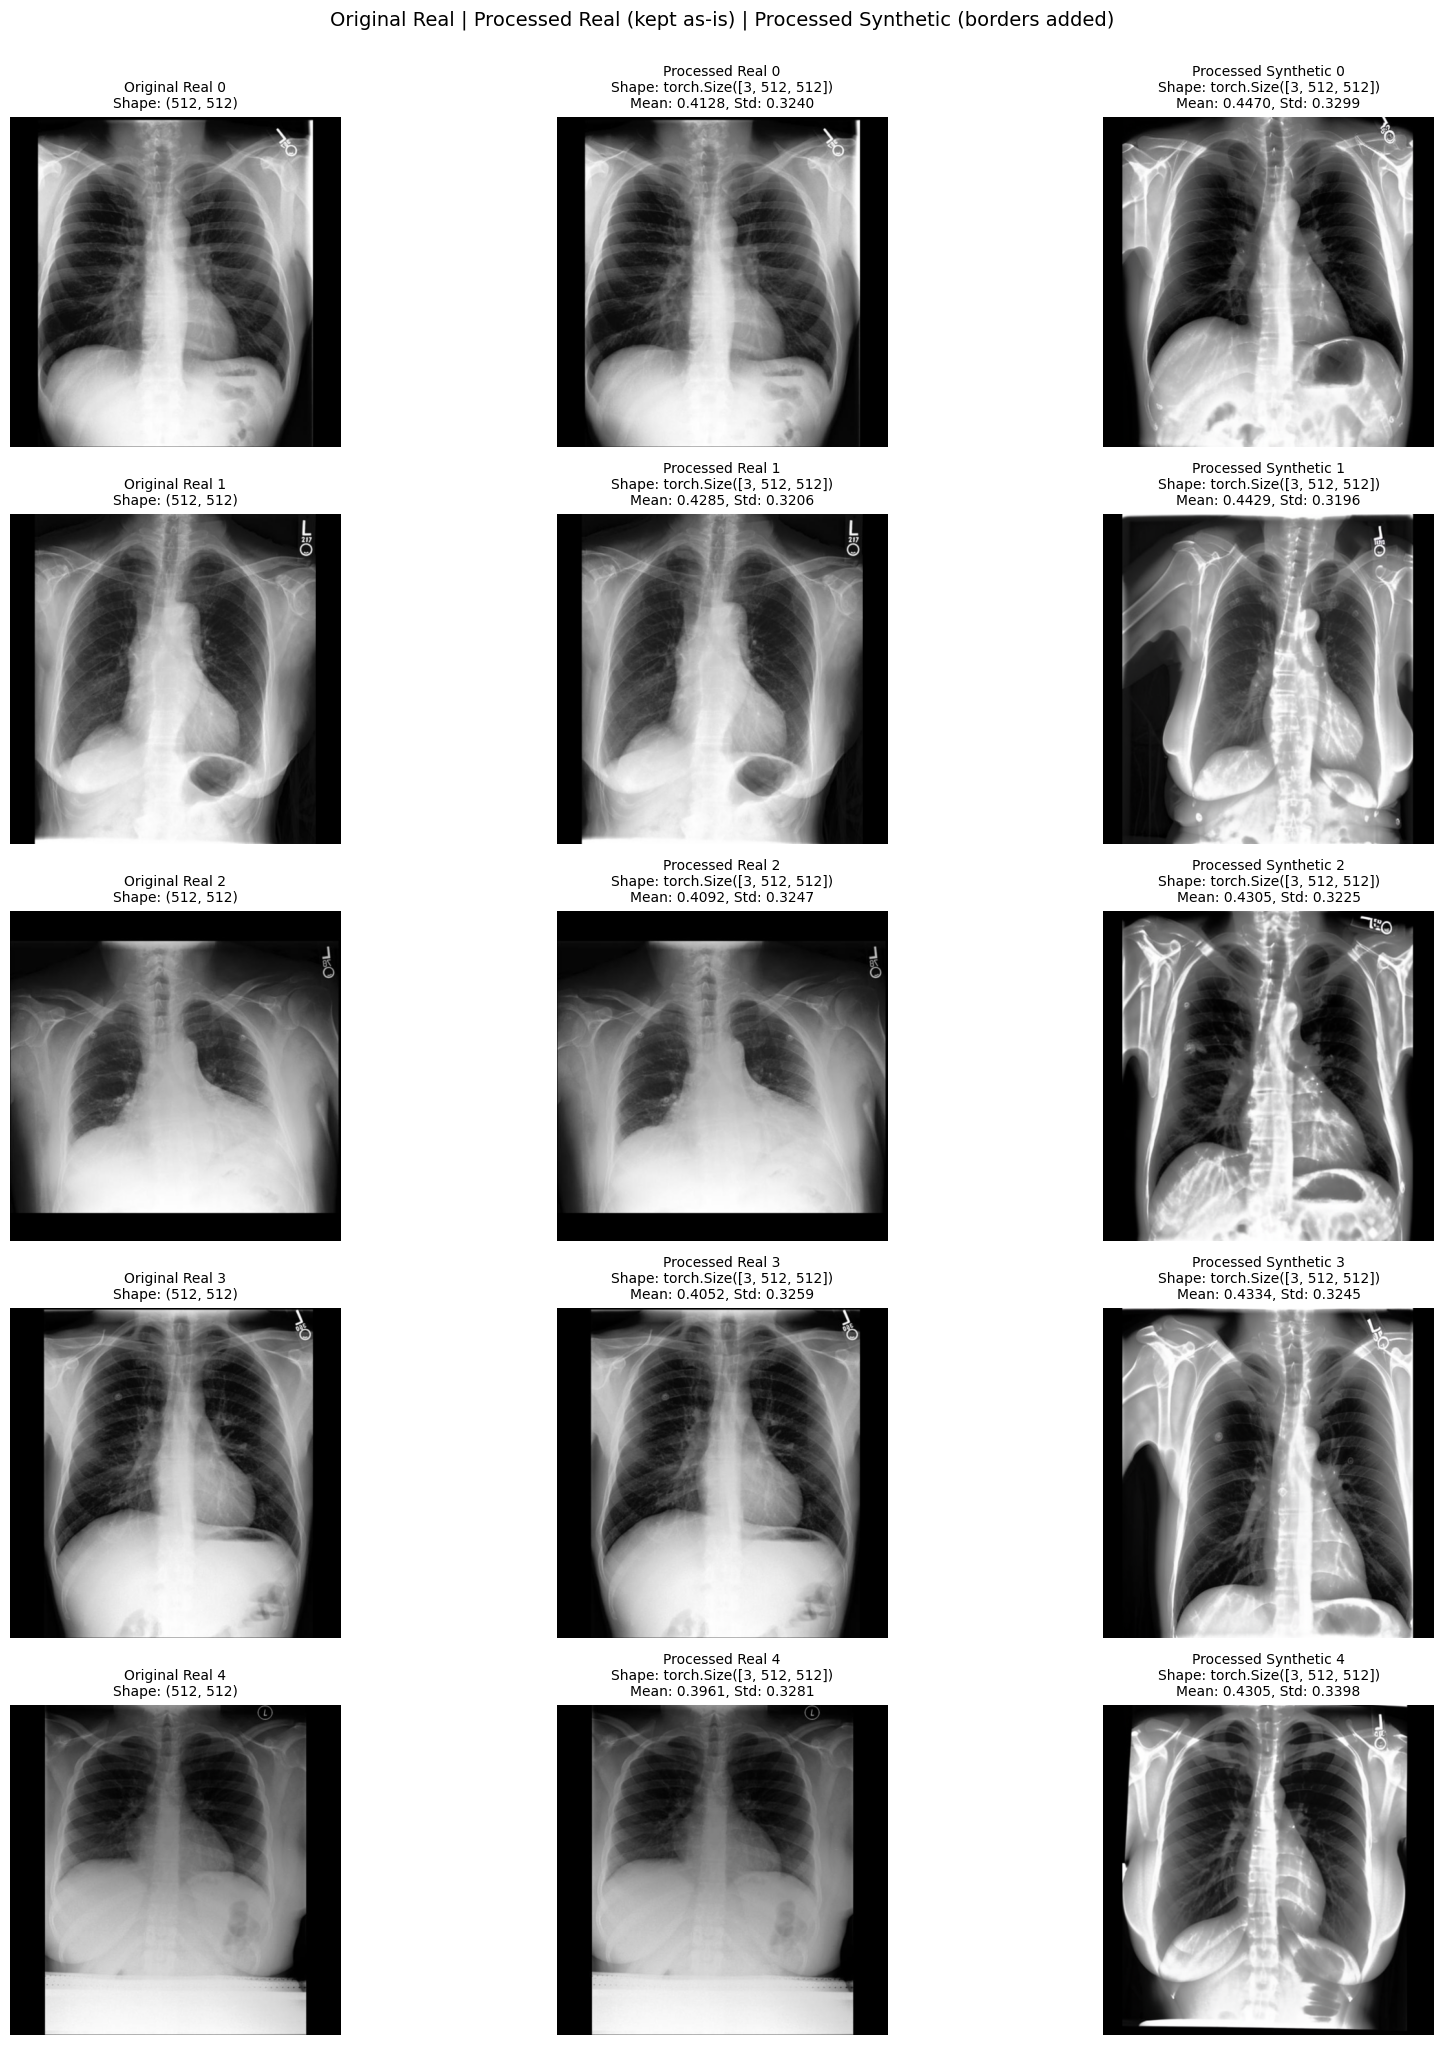

In [ ]:
# Display 3 images side-by-side: Original Real, Processed Real, Processed Synthetic
fig, axes = plt.subplots(num_pairs_to_show, 3, figsize=(18, 4 * num_pairs_to_show))
if num_pairs_to_show == 1:
    axes = axes.reshape(1, -1)

for i, pair in enumerate(image_pairs):
    # Original real image (as saved to disk)
    axes[i, 0].imshow(pair['real_original'], cmap='gray')
    axes[i, 0].set_title(f"Original Real {pair['idx']}\nShape: {pair['real_original'].size}", fontsize=10)
    axes[i, 0].axis('off')
    
    # Processed real image (kept as-is with borders)
    real_t = pair['real_processed']
    real_display = real_t.permute(1, 2, 0).numpy()
    axes[i, 1].imshow(real_display, cmap='gray')
    axes[i, 1].set_title(
        f"Processed Real {pair['idx']}\n"
        f"Shape: {real_t.shape}\n"
        f"Mean: {real_t.mean():.4f}, Std: {real_t.std():.4f}", 
        fontsize=10
    )
    axes[i, 1].axis('off')
    
    # Processed synthetic image (borders added to match)
    synth_t = pair['synth_processed']
    synth_display = synth_t.permute(1, 2, 0).numpy()
    axes[i, 2].imshow(synth_display, cmap='gray')
    axes[i, 2].set_title(
        f"Processed Synthetic {pair['idx']}\n"
        f"Shape: {synth_t.shape}\n"
        f"Mean: {synth_t.mean():.4f}, Std: {synth_t.std():.4f}", 
        fontsize=10
    )
    axes[i, 2].axis('off')

plt.tight_layout()
plt.suptitle("Original Real | Processed Real (kept as-is) | Processed Synthetic (borders added)", y=1.02, fontsize=14)
plt.show()


In [ ]:
# Side-by-side comparison of processed images
fig, axes = plt.subplots(num_pairs_to_show, 1, figsize=(16, 4 * num_pairs_to_show))
if num_pairs_to_show == 1:
    axes = [axes]

for i, pair in enumerate(image_pairs):
    real_t = pair['real_processed']
    synth_t = pair['synth_processed']
    
    # Create side-by-side comparison
    comparison = torch.cat([real_t, synth_t], dim=2)  # Concatenate horizontally
    comparison_display = comparison.permute(1, 2, 0).numpy()
    
    axes[i].imshow(comparison_display, cmap='gray')
    axes[i].axvline(x=512, color='red', linestyle='--', linewidth=2, label='Split')
    axes[i].set_title(
        f"Pair {pair['idx']}: Real (left) vs Synthetic (right) - After Border Matching\n"
        f"Real: mean={real_t.mean():.4f}, std={real_t.std():.4f} | "
        f"Synthetic: mean={synth_t.mean():.4f}, std={synth_t.std():.4f}"
    )
    axes[i].axis('off')
    
    # Show prompt if available
    if pair['prompt']:
        prompt_short = pair['prompt'][:100] + "..." if len(pair['prompt']) > 100 else pair['prompt']
        axes[i].text(0.5, -0.05, f"Prompt: {prompt_short}", transform=axes[i].transAxes, 
                    ha='center', fontsize=8, wrap=True)

plt.tight_layout()
plt.suptitle("Side-by-Side Comparison (Real vs Synthetic - After Border Matching)", y=1.02, fontsize=14)
plt.show()


In [ ]:
# Summary statistics across all pairs
print(f"\n{'='*80}")
print("SUMMARY STATISTICS ACROSS ALL PAIRS")
print(f"{'='*80}")

real_means = [pair['real_processed'].mean().item() for pair in image_pairs]
synth_means = [pair['synth_processed'].mean().item() for pair in image_pairs]
real_stds = [pair['real_processed'].std().item() for pair in image_pairs]
synth_stds = [pair['synth_processed'].std().item() for pair in image_pairs]

print(f"\nReal Images:")
print(f"  Mean: {np.mean(real_means):.4f} ± {np.std(real_means):.4f}")
print(f"  Std:  {np.mean(real_stds):.4f} ± {np.std(real_stds):.4f}")

print(f"\nSynthetic Images:")
print(f"  Mean: {np.mean(synth_means):.4f} ± {np.std(synth_means):.4f}")
print(f"  Std:  {np.mean(synth_stds):.4f} ± {np.std(synth_stds):.4f}")

print(f"\nDifference:")
mean_diff = np.mean(synth_means) - np.mean(real_means)
std_diff = np.mean(synth_stds) - np.mean(real_stds)
print(f"  Mean diff: {mean_diff:.4f}")
print(f"  Std diff:  {std_diff:.4f}")

if abs(mean_diff) < 0.05:
    print(f"\n✅ GOOD: Mean difference is small ({abs(mean_diff):.4f}), indicating consistent preprocessing")
else:
    print(f"\n⚠️ WARNING: Significant mean difference detected ({abs(mean_diff):.4f})")
    print(f"   This may indicate preprocessing inconsistencies.")


In [ ]:
# Check border consistency
print(f"\n{'='*80}")
print("BORDER CONSISTENCY CHECK")
print(f"{'='*80}")

for i, pair in enumerate(image_pairs):
    real_t = pair['real_processed']
    synth_t = pair['synth_processed']
    
    # Check border pixels (first/last 10 pixels)
    real_border = torch.cat([
        real_t[:, :10, :].flatten(),
        real_t[:, -10:, :].flatten(),
        real_t[:, :, :10].flatten(),
        real_t[:, :, -10:].flatten(),
    ])
    
    synth_border = torch.cat([
        synth_t[:, :10, :].flatten(),
        synth_t[:, -10:, :].flatten(),
        synth_t[:, :, :10].flatten(),
        synth_t[:, :, -10:].flatten(),
    ])
    
    real_black_ratio = (real_border < 0.02).float().mean().item()  # Pixels < 0.02 are considered black
    synth_black_ratio = (synth_border < 0.02).float().mean().item()
    
    print(f"\nPair {pair['idx']}:")
    print(f"  Real border black ratio:    {real_black_ratio:.2%}")
    print(f"  Synthetic border black ratio: {synth_black_ratio:.2%}")
    
    border_diff = abs(real_black_ratio - synth_black_ratio)
    if border_diff < 0.1:
        print(f"  ✅ Border consistency: Good (diff={border_diff:.2%})")
    else:
        print(f"  ⚠️ Border consistency: Different (diff={border_diff:.2%})")
